# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("ggrepel"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))


## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")

In [3]:
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)

In [4]:
available_palettes()
available_themes()

Available palettes:

 - primary

 - vibrant

 - muted_tones

Available themes:

 - default

 - publication



# Read in result files

In [5]:
# --- 1. Locate and parse the new result files ---
results_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/results_v2/"
result_files <- list.files(results_dir, pattern = "_result\\.tsv$", full.names = TRUE)
cat(length(result_files), "result files found (expect 40)\n")

known_conditions <- c("Across_GWAS_colocalized", "Within_GWAS_colocalized", "Across_full", "Within_full")
known_directions <- c("forward", "reverse", "undirected")
known_resources  <- c("STRING_experimental", "CollecTRI", "Liana", "MEROPS", "POSTAR3")

parse_filename_v2 <- function(f) {
  base <- sub("_result\\.tsv$", "", basename(f))

  match_idx <- which(sapply(known_conditions, function(cond) endsWith(base, cond)))
  eqtl_condition <- known_conditions[match_idx[1]]
  remainder <- sub(paste0("_", eqtl_condition, "$"), "", base)

  dir_idx <- which(sapply(known_directions, function(d) endsWith(remainder, d)))
  direction <- known_directions[dir_idx[1]]
  remainder <- sub(paste0("_", direction, "$"), "", remainder)

  res_idx <- which(sapply(known_resources, function(r) startsWith(remainder, r)))
  resource_name <- known_resources[res_idx[1]]
  stringency_label <- sub(paste0("^", resource_name, "_"), "", remainder)

  data.table(file = f, resource_name = resource_name, stringency_label = stringency_label,
             direction = direction, eqtl_condition = eqtl_condition)
}

file_meta <- rbindlist(lapply(result_files, parse_filename_v2))
cat("Parsed metadata:\n")
print(file_meta[, .N, by = .(resource_name, stringency_label, direction)])

# --- Relabel the STRING_experimental "lenient" stringency to reflect it's the band, not full lenient ---
file_meta[resource_name == "STRING_experimental" & stringency_label == "lenient",
          stringency_label := "lenient_band_0.1_to_0.4"]

# --- 2. Load and merge the actual result data ---
combined_results <- rbindlist(lapply(seq_len(nrow(file_meta)), function(i) {
  d <- fread(file_meta$file[i])
  d[, `:=`(resource_name = file_meta$resource_name[i],
           stringency_label = file_meta$stringency_label[i],
           direction = file_meta$direction[i],
           eqtl_condition = file_meta$eqtl_condition[i])]
  d
}), fill = TRUE)

cat(nrow(combined_results), "rows in combined_results\n")
str(combined_results)

# --- Sanity check: use the script's OWN is_untestable column directly, verify it agrees with is.na(z_score) ---
stopifnot(all(combined_results$is_untestable == is.na(combined_results$z_score)))
cat("is_untestable column verified consistent with z_score NA pattern.\n")

40 result files found (expect 40)
Parsed metadata:
          resource_name stringency_label  direction     N
                 <char>           <char>     <char> <int>
 1:           CollecTRI           strict    forward     4
 2:           CollecTRI           strict    reverse     4
 3:               Liana          lenient    forward     4
 4:               Liana          lenient    reverse     4
 5:              MEROPS           strict    forward     4
 6:              MEROPS           strict    reverse     4
 7:             POSTAR3           strict    forward     4
 8:             POSTAR3           strict    reverse     4
 9: STRING_experimental          lenient undirected     4
10: STRING_experimental           strict undirected     4
40 rows in combined_results
Classes ‘data.table’ and 'data.frame':	40 obs. of  12 variables:
 $ analysis        : chr  "CollecTRI" "CollecTRI" "CollecTRI" "CollecTRI" ...
 $ direction       : chr  "forward" "forward" "forward" "forward" ...
 $ condition

# Derived columns (edge_type, graph_type, neg_log10_p, display labels)

In [6]:
resource_colors <- c(
  "STRING_experimental" = palettes$vibrant$blue,
  "CollecTRI"            = palettes$vibrant$vermillion,
  "Liana"                = palettes$vibrant$green,
  "POSTAR3"              = palettes$vibrant$magenta,
  "MEROPS"                = palettes$vibrant$yellow
)

In [7]:
# --- 3. Derived columns (edge_type, graph_type, neg_log10_p, display labels) ---
combined_results[, edge_type := sub("_.*", "", eqtl_condition)]
combined_results[, edge_type := factor(edge_type, levels = c("Within", "Across"))]

combined_results[, graph_type := ifelse(grepl("GWAS_colocalized", eqtl_condition), "GWAS_colocalized", "full")]
combined_results[, graph_type := factor(graph_type, levels = c("full", "GWAS_colocalized"))]

combined_results[, neg_log10_p := -log10(p_enrichment)]
combined_results[, fold_enrichment := observed_hits / null_mean]
combined_results[, x_plot := ifelse(is_untestable, 1, fold_enrichment)]

resource_display_labels <- c(
  "STRING_experimental" = "PPI (STRING, experimental)",
  "CollecTRI"            = "TF-target (CollecTRI)",
  "Liana"                = "Ligand-Receptor (Liana)",
  "POSTAR3"              = "RBP-target (POSTAR3)",
  "MEROPS"               = "Peptidase-substrate (MEROPS)"
)
combined_results[, resource_display := resource_display_labels[resource_name]]

resource_colors_display <- resource_colors
names(resource_colors_display) <- resource_display_labels[names(resource_colors)]

# --- Direction display labels, for legend clarity ---
direction_display_labels <- c(
  "forward"    = "Source \u2192 Target",
  "reverse"    = "Target \u2192 Source",
  "undirected" = "Undirected (PPI)"
)
combined_results[, direction_display := direction_display_labels[direction]]

In [8]:
head(combined_results)

analysis,direction,condition,observed_hits,null_mean,null_sd,z_score,p_enrichment,is_untestable,resource_name,stringency_label,eqtl_condition,edge_type,graph_type,neg_log10_p,fold_enrichment,x_plot,resource_display,direction_display
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,2,1.7088,1.2112594,0.2404109,0.52944706,FALSE,CollecTRI,strict,Across_GWAS_colocalized,Across,GWAS_colocalized,0.2761775,1.170412,1.170412,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_full,16,10.5698,2.7442815,1.9787329,0.03989601,FALSE,CollecTRI,strict,Across_full,Across,full,1.3990705,1.513747,1.513747,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_GWAS_colocalized,12,9.1509,2.6458702,1.0768102,0.18698130,FALSE,CollecTRI,strict,Within_GWAS_colocalized,Within,GWAS_colocalized,0.7282018,1.311346,1.311346,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_full,72,54.8078,5.7804672,2.9741887,0.00339966,FALSE,CollecTRI,strict,Within_full,Within,full,2.4685645,1.313682,1.313682,TF-target (CollecTRI),Source → Target
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,0,0.0983,0.3063438,-0.3208814,1.00000000,FALSE,CollecTRI,strict,Across_GWAS_colocalized,Across,GWAS_colocalized,0.0000000,0.000000,0.000000,TF-target (CollecTRI),Target → Source
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_full,7,4.5621,1.9007643,1.2825893,0.15038496,FALSE,CollecTRI,strict,Across_full,Across,full,0.8227956,1.534381,1.534381,TF-target (CollecTRI),Target → Source


In [9]:
colnames(combined_results)

[1] "analysis"          "direction"         "condition"        
 [4] "observed_hits"     "null_mean"         "null_sd"          
 [7] "z_score"           "p_enrichment"      "is_untestable"    
[10] "resource_name"     "stringency_label"  "eqtl_condition"   
[13] "edge_type"         "graph_type"        "neg_log10_p"      
[16] "fold_enrichment"   "x_plot"            "resource_display" 
[19] "direction_display"

# Multiple testing correction

In [10]:
# --- Re-run correction fresh ---
n_total    <- nrow(combined_results)
n_testable <- sum(!combined_results$is_untestable)

combined_results[, p_adj_BH := NA_real_]
combined_results[is_untestable == FALSE, p_adj_BH := p.adjust(p_enrichment, method = "BH")]

combined_results[, p_adj_bonferroni := NA_real_]
combined_results[is_untestable == FALSE, p_adj_bonferroni := pmin(p_enrichment * n_testable, 1)]

combined_results[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]
combined_results[, sig_bonferroni_05 := !is.na(p_adj_bonferroni) & p_adj_bonferroni < 0.05]

# --- Explicit verification the columns actually exist before trusting any count ---
stopifnot(all(c("p_adj_BH", "p_adj_bonferroni", "sig_BH_05", "sig_bonferroni_05") %in% colnames(combined_results)))
cat("Correction columns confirmed present.\n")

cat("Testable:", n_testable, "| Sig BH<0.05:", sum(combined_results$sig_BH_05, na.rm = TRUE),
    "| Sig Bonferroni<0.05:", sum(combined_results$sig_bonferroni_05, na.rm = TRUE), "\n")

print(combined_results[order(p_enrichment)][,
  .(resource_display, stringency_label, direction, eqtl_condition,
    observed_hits, null_mean, z_score, p_enrichment, p_adj_BH, p_adj_bonferroni,
    sig_BH_05, sig_bonferroni_05, is_untestable)])

Correction columns confirmed present.
Testable: 33 | Sig BH<0.05: 3 | Sig Bonferroni<0.05: 1 
                resource_display        stringency_label  direction
                          <char>                  <char>     <char>
 1:   PPI (STRING, experimental) lenient_band_0.1_to_0.4 undirected
 2:   PPI (STRING, experimental)                  strict undirected
 3:        TF-target (CollecTRI)                  strict    forward
 4:   PPI (STRING, experimental) lenient_band_0.1_to_0.4 undirected
 5:   PPI (STRING, experimental)                  strict undirected
 6:      Ligand-Receptor (Liana)                 lenient    forward
 7:        TF-target (CollecTRI)                  strict    reverse
 8:        TF-target (CollecTRI)                  strict    forward
 9:         RBP-target (POSTAR3)                  strict    reverse
10:        TF-target (CollecTRI)                  strict    reverse
11:      Ligand-Receptor (Liana)                 lenient    reverse
12:        TF-target (

## Compute CI

In [11]:
# --- Re-run CI computation, confirm columns exist before plotting ---
compute_poisson_ci <- function(obs, null_mean, conf_level = 0.95) {
  ci <- poisson.test(obs, conf.level = conf_level)$conf.int
  data.table(fold_ci_low = ci[1] / null_mean, fold_ci_high = ci[2] / null_mean)
}

ci_results <- rbindlist(lapply(seq_len(nrow(combined_results)), function(i) {
  row <- combined_results[i]
  if (row$is_untestable || row$null_mean == 0) {
    data.table(fold_ci_low = NA_real_, fold_ci_high = NA_real_)
  } else {
    compute_poisson_ci(row$observed_hits, row$null_mean)
  }
}))

combined_results <- cbind(combined_results, ci_results)

stopifnot(all(c("fold_ci_low", "fold_ci_high") %in% colnames(combined_results)))
cat("CI columns confirmed present.\n")

CI columns confirmed present.


## Plot #1

In [14]:
combined_results[, row_label := paste(resource_display, direction_display, sep = " | ")]

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


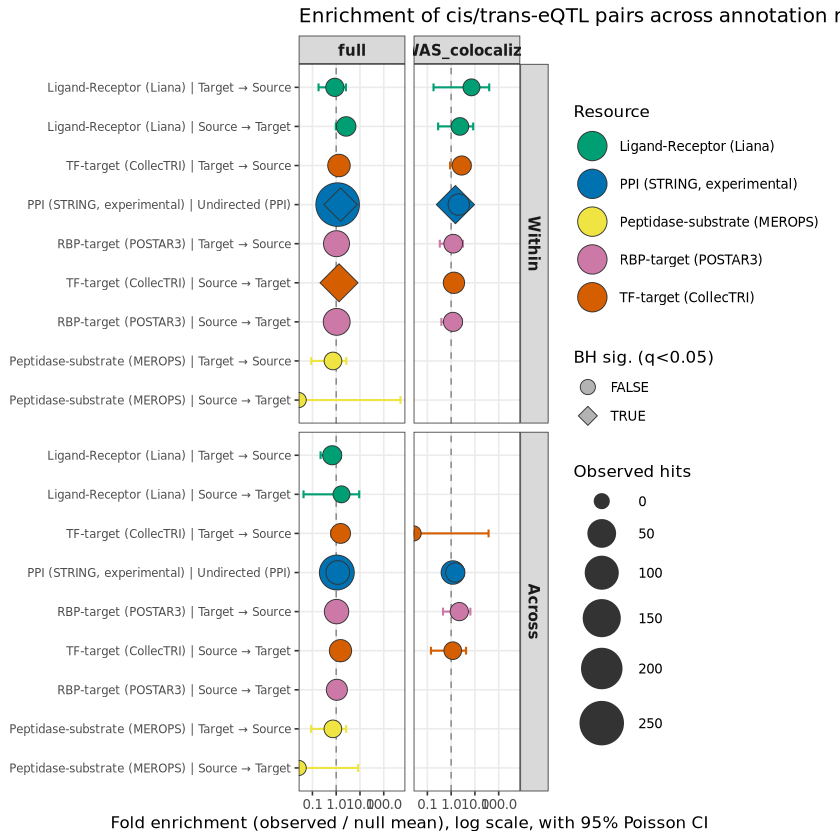

In [15]:
forest_plot <- ggplot(combined_results[is_untestable == FALSE],
                       aes(x = fold_enrichment, y = reorder(row_label, fold_enrichment))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10() +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank()
  )

print(forest_plot)

### SAVE

In [24]:
# --- Create output directory and save in all three formats ---
graph_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/"
dir.create(graph_dir, recursive = TRUE, showWarnings = FALSE)

ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.pdf"), plot = forest_plot,
       device = "pdf", width = 10, height = 8)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.png"), plot = forest_plot,
       device = "png", width = 10, height = 8, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.svg"), plot = forest_plot,
       device = "svg", width = 10, height = 8)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Peptidase-substrate (MEROPS) | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Peptidase-substrate (MEROPS) | Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'RBP-target (POSTAR3) | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'TF-target (CollecTRI) | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
War

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot.pdf" "enrichment_forest_plot.png"
[3] "enrichment_forest_plot.svg"

### Refined plot

In [21]:
# --- Rebuild row_label to include stringency, THEN build the ordering key ---
combined_results[, row_label := paste(resource_display, stringency_label, direction_display, sep = " | ")]

resource_order <- c(
  "PPI (STRING, experimental)",
  "TF-target (CollecTRI)",
  "Ligand-Receptor (Liana)",
  "RBP-target (POSTAR3)",
  "Peptidase-substrate (MEROPS)"
)
direction_order <- c("Source \u2192 Target", "Target \u2192 Source", "Undirected (PPI)")

row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]

stopifnot(all(!is.na(row_order_key$resource_rank)))
stopifnot(!any(duplicated(row_order_key$row_label)))  # explicit check this time, catches the exact bug you just hit

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label, resource_display, stringency_label, direction_display)])

                                                                  row_label
                                                                     <char>
 1:                  PPI (STRING, experimental) | strict | Undirected (PPI)
 2: PPI (STRING, experimental) | lenient_band_0.1_to_0.4 | Undirected (PPI)
 3:                        TF-target (CollecTRI) | strict | Source → Target
 4:                        TF-target (CollecTRI) | strict | Target → Source
 5:                     Ligand-Receptor (Liana) | lenient | Source → Target
 6:                     Ligand-Receptor (Liana) | lenient | Target → Source
 7:                         RBP-target (POSTAR3) | strict | Source → Target
 8:                         RBP-target (POSTAR3) | strict | Target → Source
 9:                 Peptidase-substrate (MEROPS) | strict | Source → Target
10:                 Peptidase-substrate (MEROPS) | strict | Target → Source
                resource_display        stringency_label direction_display
             

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”


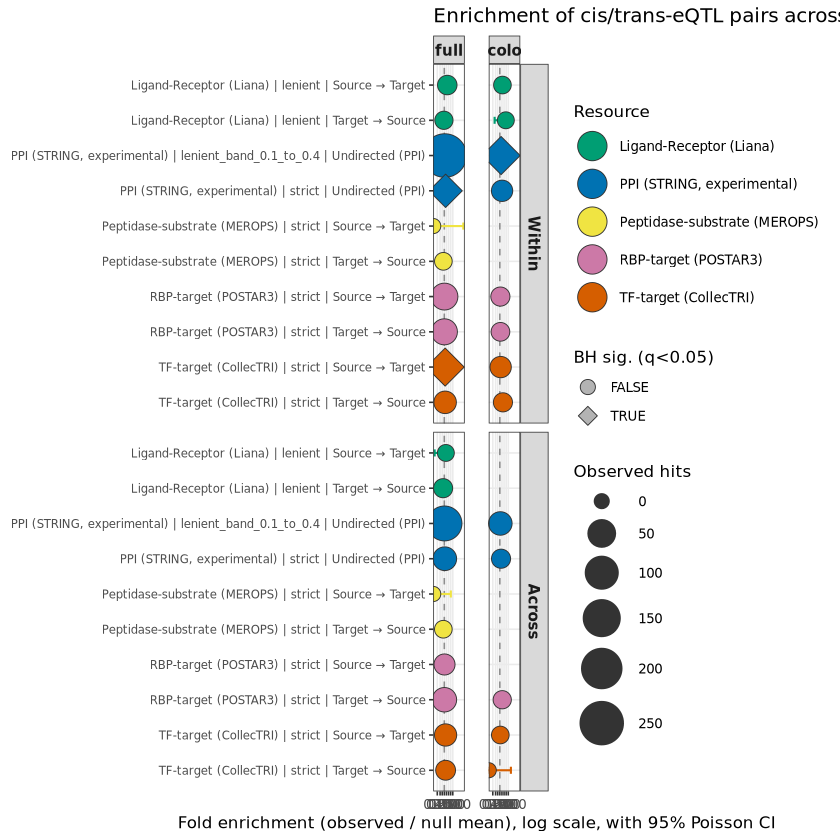

In [22]:
# --- Row label now includes stringency, so strict vs lenient-band STRING get separate rows ---
combined_results[, row_label := paste(resource_display, stringency_label, direction_display, sep = " | ")]

forest_plot_v3 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = fold_enrichment, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(1, "lines")
  )

print(forest_plot_v3)

In [25]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.pdf"), plot = forest_plot_v3,
       device = "pdf", width = 16, height = 8)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.png"), plot = forest_plot_v3,
       device = "png", width = 16, height = 8, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.svg"), plot = forest_plot_v3,
       device = "svg", width = 16, height = 8)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v3")

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'TF-target (CollecTRI) | strict | Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'TF-target (CollecTRI) | strict | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“fo

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v3.pdf" "enrichment_forest_plot_v3.png"
[3] "enrichment_forest_plot_v3.svg"

## Refined plot 2

In [26]:
# --- Build display stringency label per resource ---
# For PPI (STRING, experimental): stringency becomes the actual score threshold.
# For every other resource: drop the stringency segment entirely (only one
# stringency per resource will appear in the methods, so it's redundant here).

combined_results[, stringency_display := fifelse(
  resource_display == "PPI (STRING, experimental)",
  fifelse(stringency_label == "strict", "score \u2265 0.4",
  fifelse(stringency_label == "lenient_band_0.1_to_0.4", "0.1 < score \u2264 0.4", stringency_label)),
  NA_character_   # drop for all other resources
)]

# --- Replace " | " separator with a newline for multi-line y-axis labels ---
combined_results[, row_label := fifelse(
  is.na(stringency_display),
  paste(resource_display, direction_display, sep = "\n"),
  paste(resource_display, stringency_display, direction_display, sep = "\n")
)]

# --- Rebuild the ordering on the new row_label text (same logic as before) ---
row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]
stopifnot(all(!is.na(row_order_key$resource_rank)))

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label)])

                                                          row_label
                                                             <char>
 1:       PPI (STRING, experimental)\nscore ≥ 0.4\nUndirected (PPI)
 2: PPI (STRING, experimental)\n0.1 < score ≤ 0.4\nUndirected (PPI)
 3:                          TF-target (CollecTRI)\nSource → Target
 4:                          TF-target (CollecTRI)\nTarget → Source
 5:                        Ligand-Receptor (Liana)\nSource → Target
 6:                        Ligand-Receptor (Liana)\nTarget → Source
 7:                           RBP-target (POSTAR3)\nSource → Target
 8:                           RBP-target (POSTAR3)\nTarget → Source
 9:                   Peptidase-substrate (MEROPS)\nSource → Target
10:                   Peptidase-substrate (MEROPS)\nTarget → Source


Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”


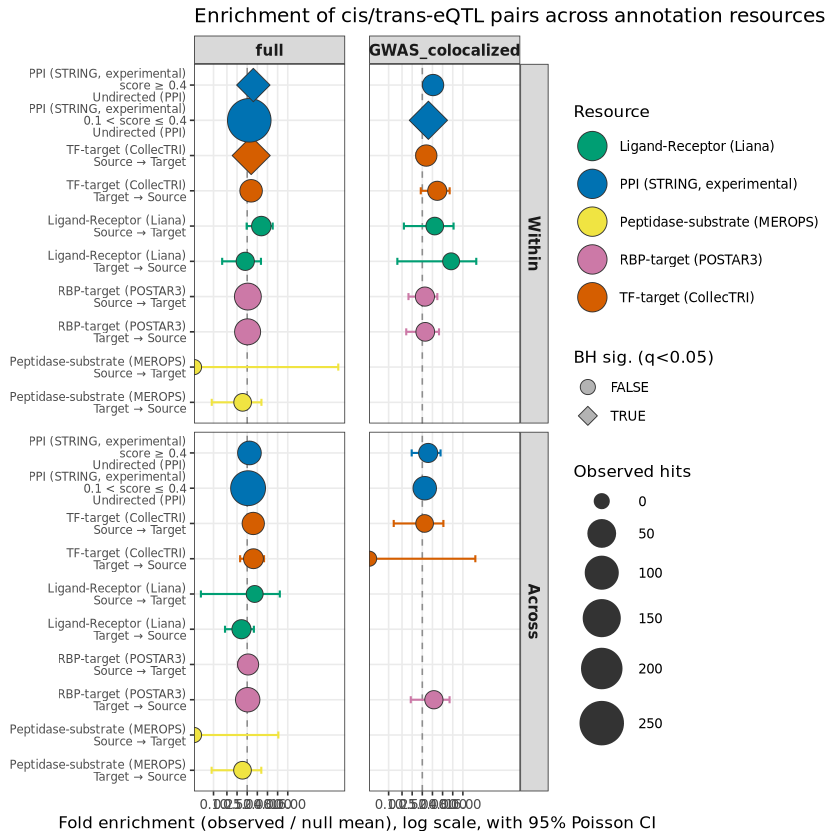

In [27]:
forest_plot_v5 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = fold_enrichment, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7, lineheight = 0.85),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(1, "lines")
  )

print(forest_plot_v5)

## SAVE

In [29]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.pdf"), plot = forest_plot_v5,
       device = "pdf", width = 16, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.png"), plot = forest_plot_v5,
       device = "png", width = 16, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.svg"), plot = forest_plot_v5,
       device = "svg", width = 16, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v5")

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v5.pdf" "enrichment_forest_plot_v5.png"
[3] "enrichment_forest_plot_v5.svg"

# refined 3

In [30]:
# --- Confirm which plotted points have observed_hits == 0 ---
zero_hit_rows <- combined_results[is_untestable == FALSE & observed_hits == 0]
print(zero_hit_rows[, .(resource_display, direction, eqtl_condition, observed_hits, null_mean, fold_enrichment, fold_ci_low, fold_ci_high)])

               resource_display direction          eqtl_condition observed_hits
                         <char>    <char>                  <char>         <int>
1:        TF-target (CollecTRI)   reverse Across_GWAS_colocalized             0
2: Peptidase-substrate (MEROPS)   forward             Across_full             0
3: Peptidase-substrate (MEROPS)   forward             Within_full             0
   null_mean fold_enrichment fold_ci_low fold_ci_high
       <num>           <num>       <num>        <num>
1:    0.0983               0           0    37.526749
2:    0.4388               0           0     8.406744
3:    0.0073               0           0   505.325953


In [31]:
# --- Explicit flag for zero-hit rows, handled separately from the log-scale mapping ---
combined_results[, is_zero_hit := is_untestable == FALSE & observed_hits == 0]

# For plotting position only: zero-hit rows get placed at the lower x-limit,
# with a distinct shape/label rather than pretending they have a real fold value
x_axis_floor <- 0.05  # just below the smallest real non-zero fold value on the log scale

combined_results[, x_plot_final := fifelse(is_zero_hit, x_axis_floor, fold_enrichment)]
combined_results[, ci_low_plot  := fifelse(is_zero_hit, NA_real_, fold_ci_low)]   # no CI whisker for these
combined_results[, ci_high_plot := fifelse(is_zero_hit, NA_real_, fold_ci_high)]

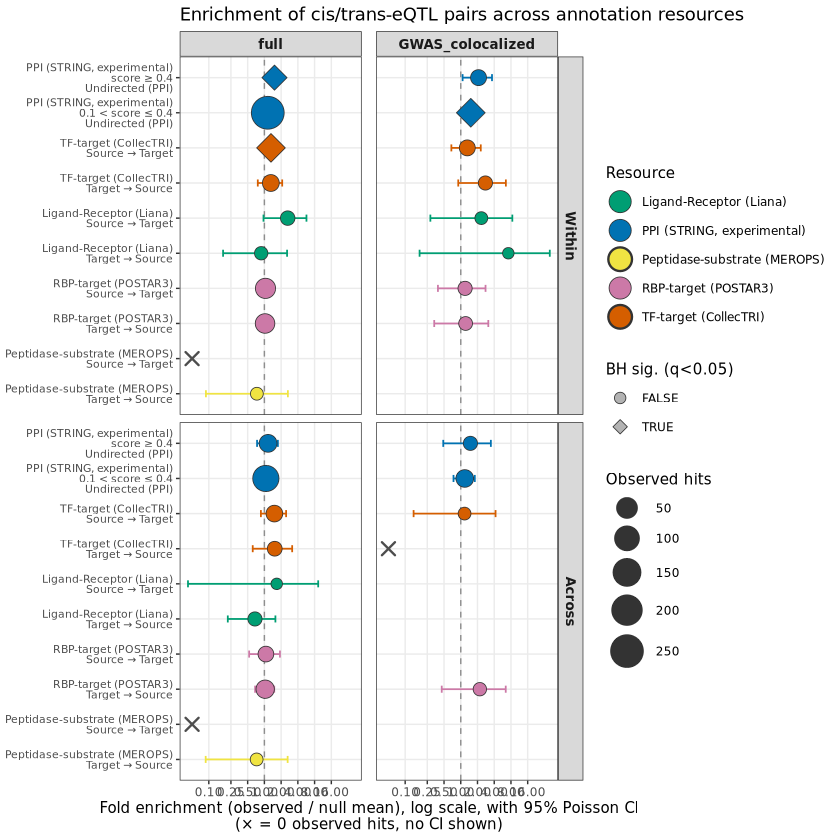

In [32]:
forest_plot_v6 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9) +
  theme(
    axis.text.y = element_text(size = 6.5, lineheight = 0.8),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v6)

In [33]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.pdf"), plot = forest_plot_v6,
       device = "pdf", width = 12, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.png"), plot = forest_plot_v6,
       device = "png", width = 12, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.svg"), plot = forest_plot_v6,
       device = "svg", width = 12, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v6")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v6.pdf" "enrichment_forest_plot_v6.png"
[3] "enrichment_forest_plot_v6.svg"

# refined 4

In [34]:
# --- Relabel direction display: Source -> cis-eQTL, Target -> trans-eQTL ---
direction_display_labels <- c(
  "forward"    = "cis-eQTL \u2192 trans-eQTL",
  "reverse"    = "trans-eQTL \u2192 cis-eQTL",
  "undirected" = "Undirected (PPI)"
)
combined_results[, direction_display := direction_display_labels[direction]]

direction_order <- c("cis-eQTL \u2192 trans-eQTL", "trans-eQTL \u2192 cis-eQTL", "Undirected (PPI)")

# --- Rebuild row_label with the new direction text ---
combined_results[, row_label := fifelse(
  is.na(stringency_display),
  paste(resource_display, direction_display, sep = "\n"),
  paste(resource_display, stringency_display, direction_display, sep = "\n")
)]

# --- Rebuild ordering on the new row_label text ---
row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]
stopifnot(all(!is.na(row_order_key$resource_rank)))

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label)])

                                                          row_label
                                                             <char>
 1:       PPI (STRING, experimental)\nscore ≥ 0.4\nUndirected (PPI)
 2: PPI (STRING, experimental)\n0.1 < score ≤ 0.4\nUndirected (PPI)
 3:                    TF-target (CollecTRI)\ncis-eQTL → trans-eQTL
 4:                    TF-target (CollecTRI)\ntrans-eQTL → cis-eQTL
 5:                  Ligand-Receptor (Liana)\ncis-eQTL → trans-eQTL
 6:                  Ligand-Receptor (Liana)\ntrans-eQTL → cis-eQTL
 7:                     RBP-target (POSTAR3)\ncis-eQTL → trans-eQTL
 8:                     RBP-target (POSTAR3)\ntrans-eQTL → cis-eQTL
 9:             Peptidase-substrate (MEROPS)\ncis-eQTL → trans-eQTL
10:             Peptidase-substrate (MEROPS)\ntrans-eQTL → cis-eQTL


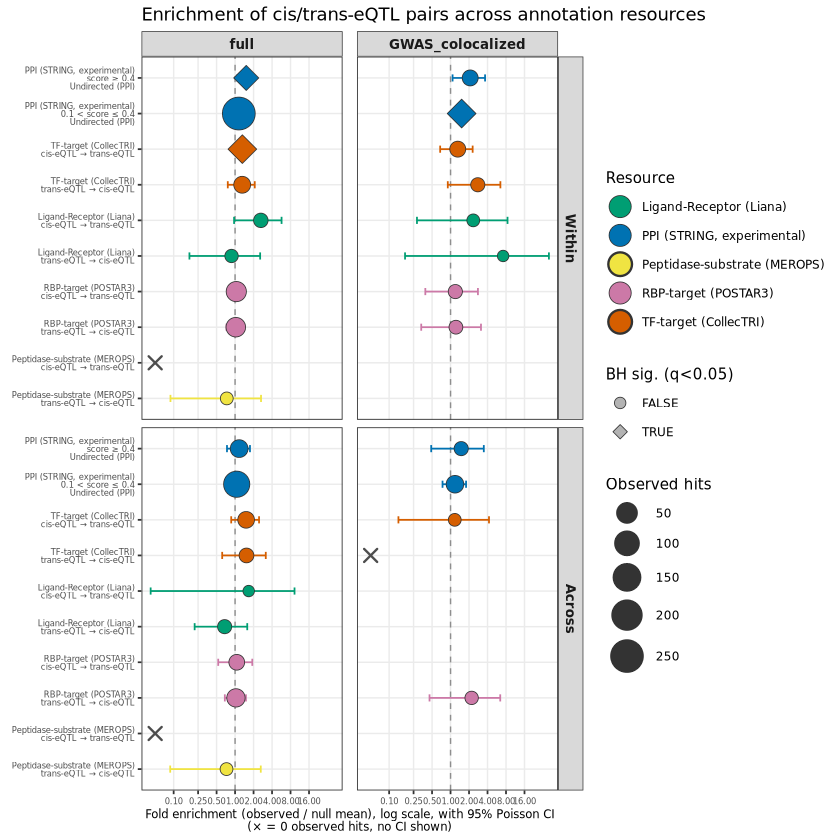

In [35]:
forest_plot_v7 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5, lineheight = 0.8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v7)

In [36]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.pdf"), plot = forest_plot_v7,
       device = "pdf", width = 12, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.png"), plot = forest_plot_v7,
       device = "png", width = 12, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.svg"), plot = forest_plot_v7,
       device = "svg", width = 12, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v7")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v7.pdf" "enrichment_forest_plot_v7.png"
[3] "enrichment_forest_plot_v7.svg"

In [37]:
forest_plot_v8 <- forest_plot_v7  # same plot object, no theme/geometry changes needed

ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.pdf"), plot = forest_plot_v8,
       device = "pdf", width = 180, height = 130, units = "mm")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.png"), plot = forest_plot_v8,
       device = "png", width = 180, height = 130, units = "mm", dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.svg"), plot = forest_plot_v8,
       device = "svg", width = 180, height = 130, units = "mm")

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v8")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v8.pdf" "enrichment_forest_plot_v8.png"
[3] "enrichment_forest_plot_v8.svg"

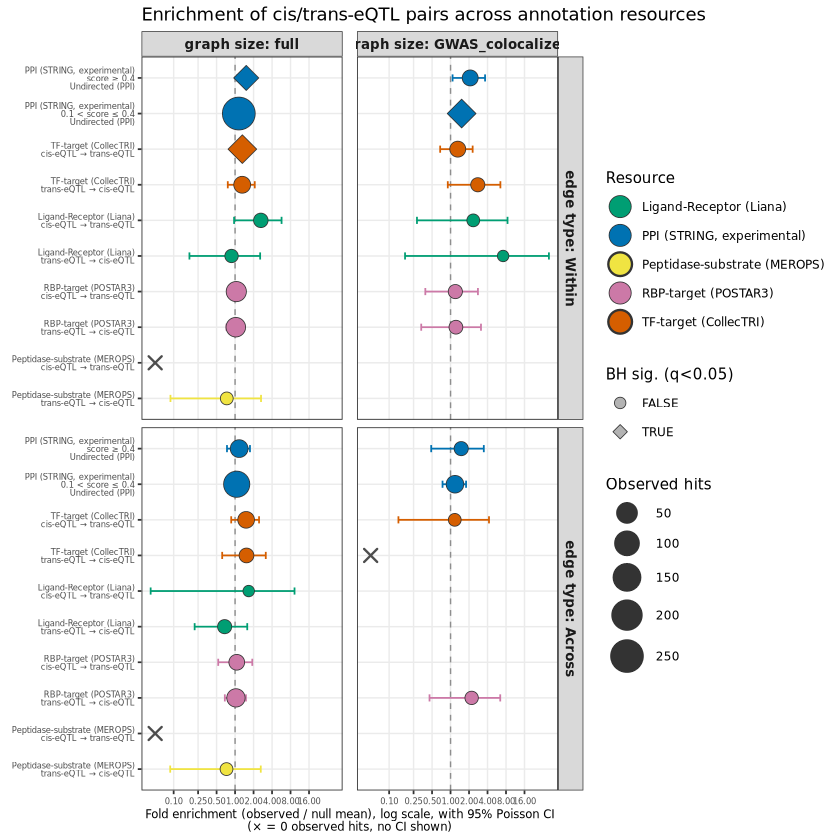

In [38]:
forest_plot_v9 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(
    rows = vars(edge_type), cols = vars(graph_type),
    scales = "free_y", space = "free_y",
    labeller = labeller(
      edge_type  = as_labeller(function(x) paste("edge type:", x)),
      graph_type = as_labeller(function(x) paste("graph size:", x))
    )
  ) +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5, lineheight = 0.8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v9)

In [39]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.pdf"), plot = forest_plot_v9,
       device = "pdf", width = 180, height = 130, units = "mm")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.png"), plot = forest_plot_v9,
       device = "png", width = 180, height = 130, units = "mm", dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.svg"), plot = forest_plot_v9,
       device = "svg", width = 180, height = 130, units = "mm")

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v9")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v9.pdf" "enrichment_forest_plot_v9.png"
[3] "enrichment_forest_plot_v9.svg"

# SAVE object for replotting

In [40]:
# --- Save combined_results in its fully processed form for future replotting ---
# NOTE: combined_results now has factor-leveled columns (row_label, edge_type,
# graph_type) whose ORDER encodes the plotting logic (resource-grouped, etc.).
# .rds preserves factor levels/order exactly; .tsv does NOT (factors get
# written as plain strings, losing the encoded order) - so .rds is the
# reload-for-replotting copy, .tsv is for inspection/sharing only.

save_path_rds <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/combined_results_enrichment.rds"
save_path_tsv <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/combined_results_enrichment.tsv"

saveRDS(combined_results, save_path_rds)
fwrite(combined_results, save_path_tsv, sep = "\t")

cat("Saved", nrow(combined_results), "rows,", ncol(combined_results), "columns\n")
print(colnames(combined_results))

# --- Verify before trusting: reload and spot-check row count, key stats, and factor level order ---
check <- readRDS(save_path_rds)
stopifnot(nrow(check) == nrow(combined_results))
stopifnot(identical(levels(check$row_label), levels(combined_results$row_label)))
stopifnot(sum(check$sig_BH_05, na.rm = TRUE) == sum(combined_results$sig_BH_05, na.rm = TRUE))
cat("Reload check passed: row count, row_label factor order, and BH-significant count all match.\n")

Saved 40 rows, 31 columns
 [1] "analysis"           "direction"          "condition"         
 [4] "observed_hits"      "null_mean"          "null_sd"           
 [7] "z_score"            "p_enrichment"       "is_untestable"     
[10] "resource_name"      "stringency_label"   "eqtl_condition"    
[13] "edge_type"          "graph_type"         "neg_log10_p"       
[16] "fold_enrichment"    "x_plot"             "resource_display"  
[19] "direction_display"  "p_adj_BH"           "p_adj_bonferroni"  
[22] "sig_BH_05"          "sig_bonferroni_05"  "fold_ci_low"       
[25] "fold_ci_high"       "row_label"          "stringency_display"
[28] "is_zero_hit"        "x_plot_final"       "ci_low_plot"       
[31] "ci_high_plot"      
Reload check passed: row count, row_label factor order, and BH-significant count all match.


In [41]:
head(combined_results)

analysis,direction,condition,observed_hits,null_mean,null_sd,z_score,p_enrichment,is_untestable,resource_name,⋯,sig_BH_05,sig_bonferroni_05,fold_ci_low,fold_ci_high,row_label,stringency_display,is_zero_hit,x_plot_final,ci_low_plot,ci_high_plot
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,⋯,<lgl>,<lgl>,<dbl>,<dbl>,<fct>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,2,1.7088,1.2112594,0.2404109,0.52944706,FALSE,CollecTRI,⋯,FALSE,FALSE,0.1417423,4.227931,TF-target (CollecTRI) cis-eQTL → trans-eQTL,NA,FALSE,1.170412,0.1417423,4.227931
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_full,16,10.5698,2.7442815,1.9787329,0.03989601,FALSE,CollecTRI,⋯,FALSE,FALSE,0.8652370,2.458230,TF-target (CollecTRI) cis-eQTL → trans-eQTL,NA,FALSE,1.513747,0.8652370,2.458230
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_GWAS_colocalized,12,9.1509,2.6458702,1.0768102,0.18698130,FALSE,CollecTRI,⋯,FALSE,FALSE,0.6775918,2.290658,TF-target (CollecTRI) cis-eQTL → trans-eQTL,NA,FALSE,1.311346,0.6775918,2.290658
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_full,72,54.8078,5.7804672,2.9741887,0.00339966,FALSE,CollecTRI,⋯,TRUE,FALSE,1.0278750,1.654365,TF-target (CollecTRI) cis-eQTL → trans-eQTL,NA,FALSE,1.313682,1.0278750,1.654365
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,0,0.0983,0.3063438,-0.3208814,1.00000000,FALSE,CollecTRI,⋯,FALSE,FALSE,0.0000000,37.526749,TF-target (CollecTRI) trans-eQTL → cis-eQTL,NA,TRUE,0.050000,NA,NA
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_full,7,4.5621,1.9007643,1.2825893,0.15038496,FALSE,CollecTRI,⋯,FALSE,FALSE,0.6169008,3.161411,TF-target (CollecTRI) trans-eQTL → cis-eQTL,NA,FALSE,1.534381,0.6169008,3.161411
